# Edge Detection: From Smoothing to Canny

**Edge detection** identifies locations in an image where the intensity changes sharply — boundaries of objects, texture transitions, illumination steps. It is among the oldest and most studied problems in computer vision and image analysis.

The fundamental challenge is that real images contain both **signal** (meaningful edges) and **noise** (random pixel fluctuations), and large gradients may arise from both. The classical solution is to **first smooth** then **differentiate**.

## Gaussian scale-space

Smoothing an image $f$ with a Gaussian of standard deviation $\sigma$ produces
$$
f_\sigma = G_\sigma * f, \qquad G_\sigma(x) = \frac{1}{2\pi\sigma^2} e^{-\|x\|^2/(2\sigma^2)}.
$$
As $\sigma$ grows, fine details vanish and only coarse structures survive — this is the **scale-space** of Koenderink and Witkin. Edges at scale $\sigma$ are features of $f_\sigma$.

## Three classical edge criteria

1. **Gradient magnitude** $\|\nabla f_\sigma\|$: large where intensity changes fast. Threshold to obtain binary edges.

2. **Laplacian zero-crossings** $\Delta f_\sigma = 0$: the Laplacian $\Delta f = \partial_{xx}f + \partial_{yy}f$ changes sign across a ridge in $\|\nabla f\|$. Marr–Hildreth (1980) proposed detecting these zero-crossings as edges.

3. **Canny edges** (1986): edges are located at **non-maximum suppression** points of $\|\nabla f_\sigma\|$ along the gradient direction, i.e. where
$$
\langle \nabla^2 f_\sigma \cdot \nabla f_\sigma,\, \nabla f_\sigma \rangle = 0 \quad \text{and} \quad \|\nabla f_\sigma\| > \tau.
$$
This selects precisely one-pixel-wide ridges of gradient magnitude.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from ipywidgets import interact, FloatSlider

plt.rcParams["figure.dpi"] = 120

## Synthetic test image

We build a clean test image with a variety of edge types: straight lines, a disk, a smooth gradient region, and a textured patch. This lets us evaluate each detector on known ground truth.

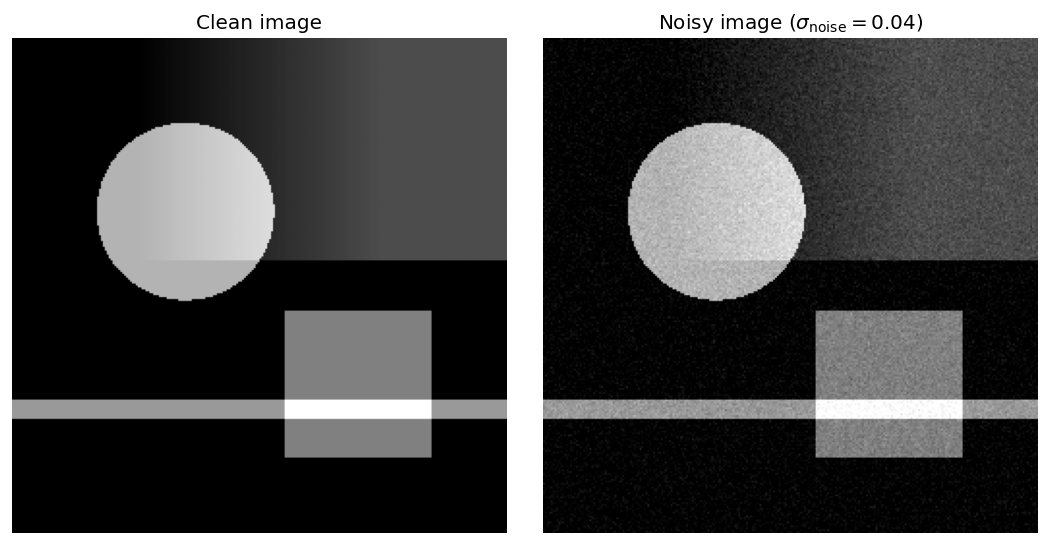

In [2]:
n = 256
x = np.linspace(0, 1, n)
X, Y = np.meshgrid(x, x)

# Disk
img = np.zeros((n, n))
img += 0.7 * ((X - 0.35)**2 + (Y - 0.35)**2 < 0.18**2).astype(float)
# Rectangle
img += 0.5 * ((X > 0.55) & (X < 0.85) & (Y > 0.55) & (Y < 0.85)).astype(float)
# Smooth ramp
img += 0.3 * np.clip(X * 2 - 0.5, 0, 1) * (Y < 0.45)
# Thin stripe
img += 0.6 * (np.abs(Y - 0.75) < 0.02).astype(float)
img = np.clip(img, 0, 1)

# Add mild noise
rng = np.random.default_rng(3)
img_noisy = np.clip(img + rng.normal(0, 0.04, img.shape), 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Clean image"); axes[0].axis("off")
axes[1].imshow(img_noisy, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Noisy image ($\\sigma_{\\mathrm{noise}}=0.04$)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Gaussian scale-space and gradient magnitude

We implement discrete gradient operators using centered differences on a periodic domain. The gradient magnitude is $\|\nabla f_\sigma\| = \sqrt{(\partial_x f_\sigma)^2 + (\partial_y f_\sigma)^2}$.

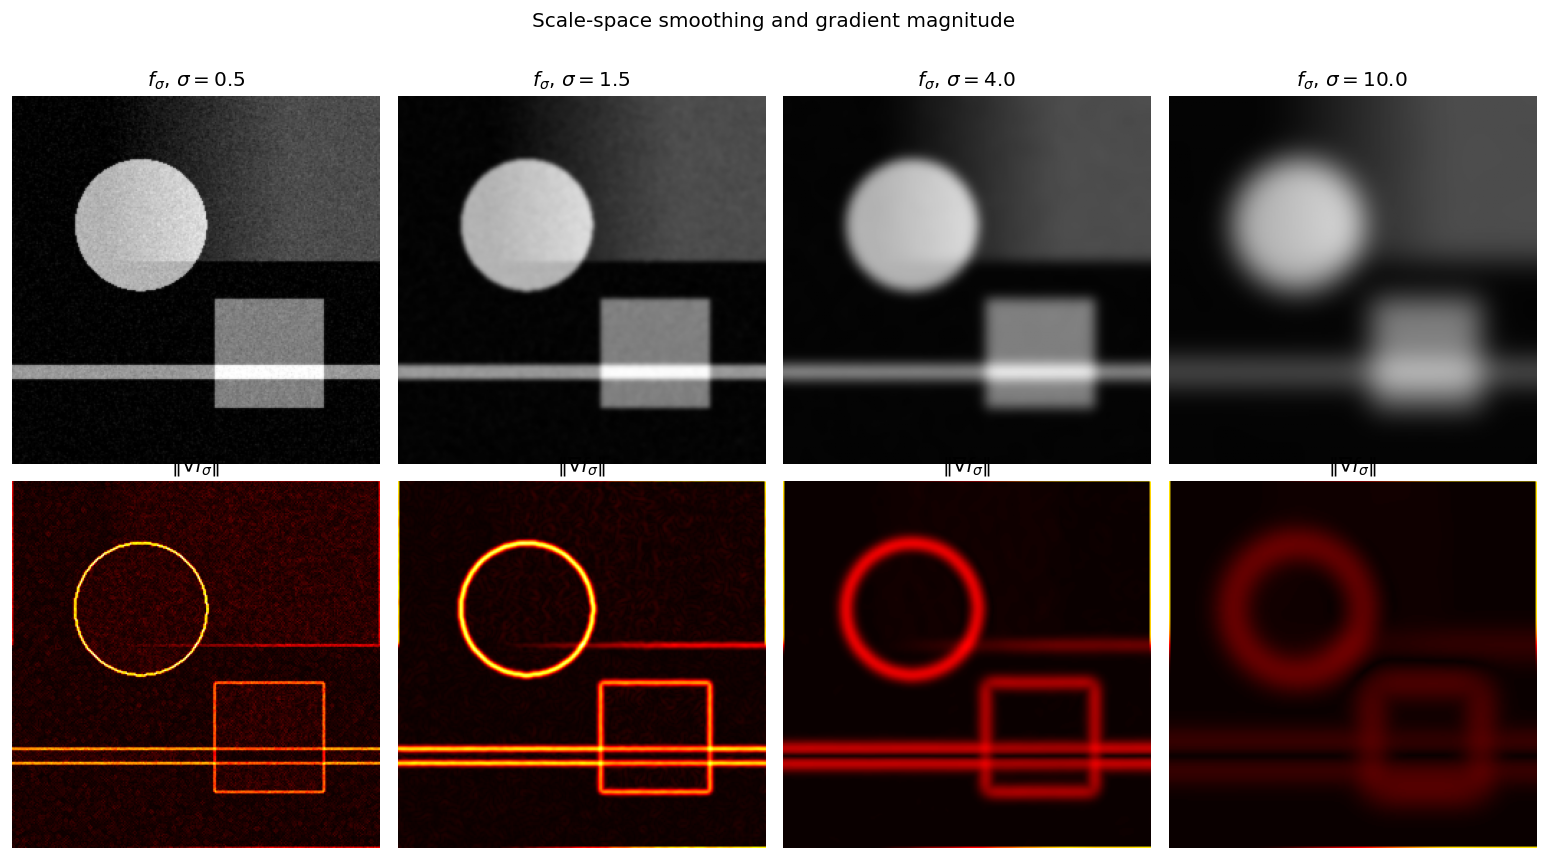

In [3]:
def grad(f):
    """Centered finite difference gradient (periodic boundaries)."""
    dx = (np.roll(f, -1, axis=1) - np.roll(f, 1, axis=1)) / 2
    dy = (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / 2
    return dx, dy


def laplacian(f):
    return (np.roll(f,-1,0)+np.roll(f,1,0)+np.roll(f,-1,1)+np.roll(f,1,1) - 4*f)


sigmas = [0.5, 1.5, 4.0, 10.0]
fig, axes = plt.subplots(2, 4, figsize=(13, 7))

for j, sigma in enumerate(sigmas):
    fs = gaussian_filter(img_noisy, sigma)
    gx, gy = grad(fs)
    gmag = np.sqrt(gx**2 + gy**2)

    axes[0, j].imshow(fs, cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"$f_\\sigma$, $\\sigma={sigma}$"); axes[0, j].axis("off")

    axes[1, j].imshow(gmag, cmap="hot", vmin=0, vmax=gmag.max())
    axes[1, j].set_title(f"$\\|\\nabla f_\\sigma\\|$"); axes[1, j].axis("off")

fig.suptitle("Scale-space smoothing and gradient magnitude", y=1.02)
plt.tight_layout()
plt.show()

## Laplacian zero-crossings

A zero-crossing of $\Delta f_\sigma$ occurs where the Laplacian changes sign. We detect them as locations where adjacent pixels have opposite signs. Larger $\sigma$ produces smoother, thicker edges at coarser scales.

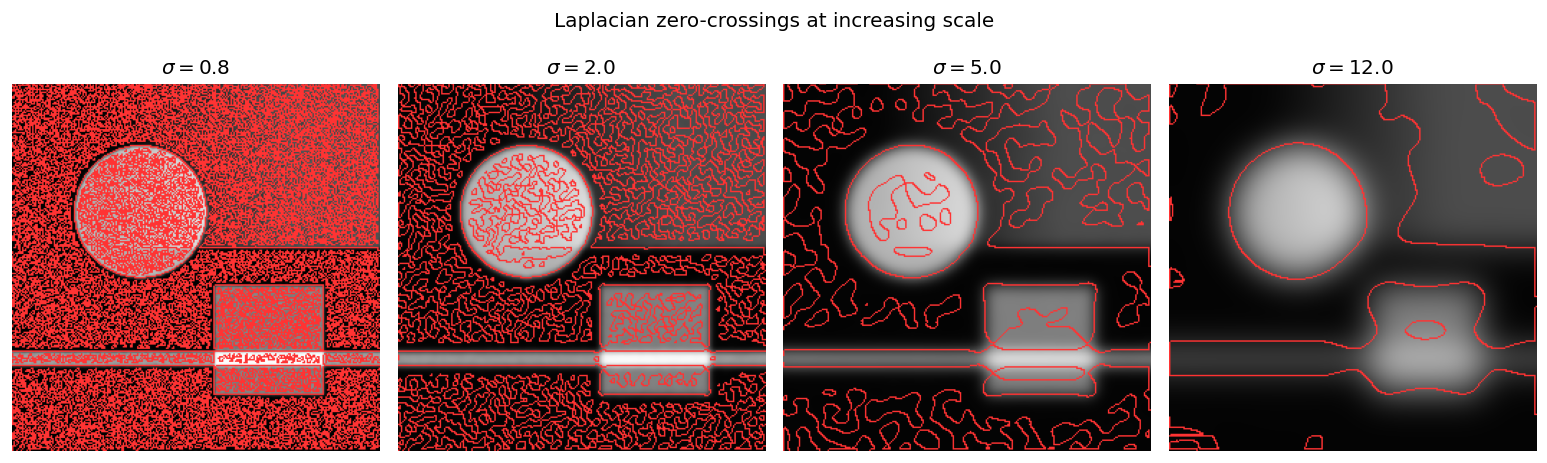

In [4]:
def zero_crossings(lap):
    """Boolean mask: True where Laplacian changes sign between adjacent pixels."""
    zc = np.zeros_like(lap, dtype=bool)
    zc |= np.pad(lap[:-1, :] * lap[1:, :] < 0, ((0, 1), (0, 0)))
    zc |= np.pad(lap[:, :-1] * lap[:, 1:] < 0, ((0, 0), (0, 1)))
    return zc


fig, axes = plt.subplots(1, 4, figsize=(13, 3.8))
for ax, sigma in zip(axes, [0.8, 2.0, 5.0, 12.0]):
    fs = gaussian_filter(img_noisy, sigma)
    lap = laplacian(fs)
    zc = zero_crossings(lap)
    # overlay on smoothed image
    disp = np.stack([fs, fs, fs], axis=-1)
    disp[zc] = [1.0, 0.2, 0.2]
    ax.imshow(np.clip(disp, 0, 1))
    ax.set_title(f"$\\sigma = {sigma}$"); ax.axis("off")
fig.suptitle("Laplacian zero-crossings at increasing scale", y=1.02)
plt.tight_layout()
plt.show()

## Canny-style edges

The Canny criterion finds the zero-crossings of $\langle H(f_\sigma)\,\nabla f_\sigma, \nabla f_\sigma \rangle$ where $H(f) = \nabla^2 f$ is the Hessian. Equivalently, edges are the zero-crossings of the **directional second derivative** of $f_\sigma$ along the gradient direction — the one-pixel-wide ridges of gradient magnitude.

We implement this from scratch using finite-difference Hessian entries.

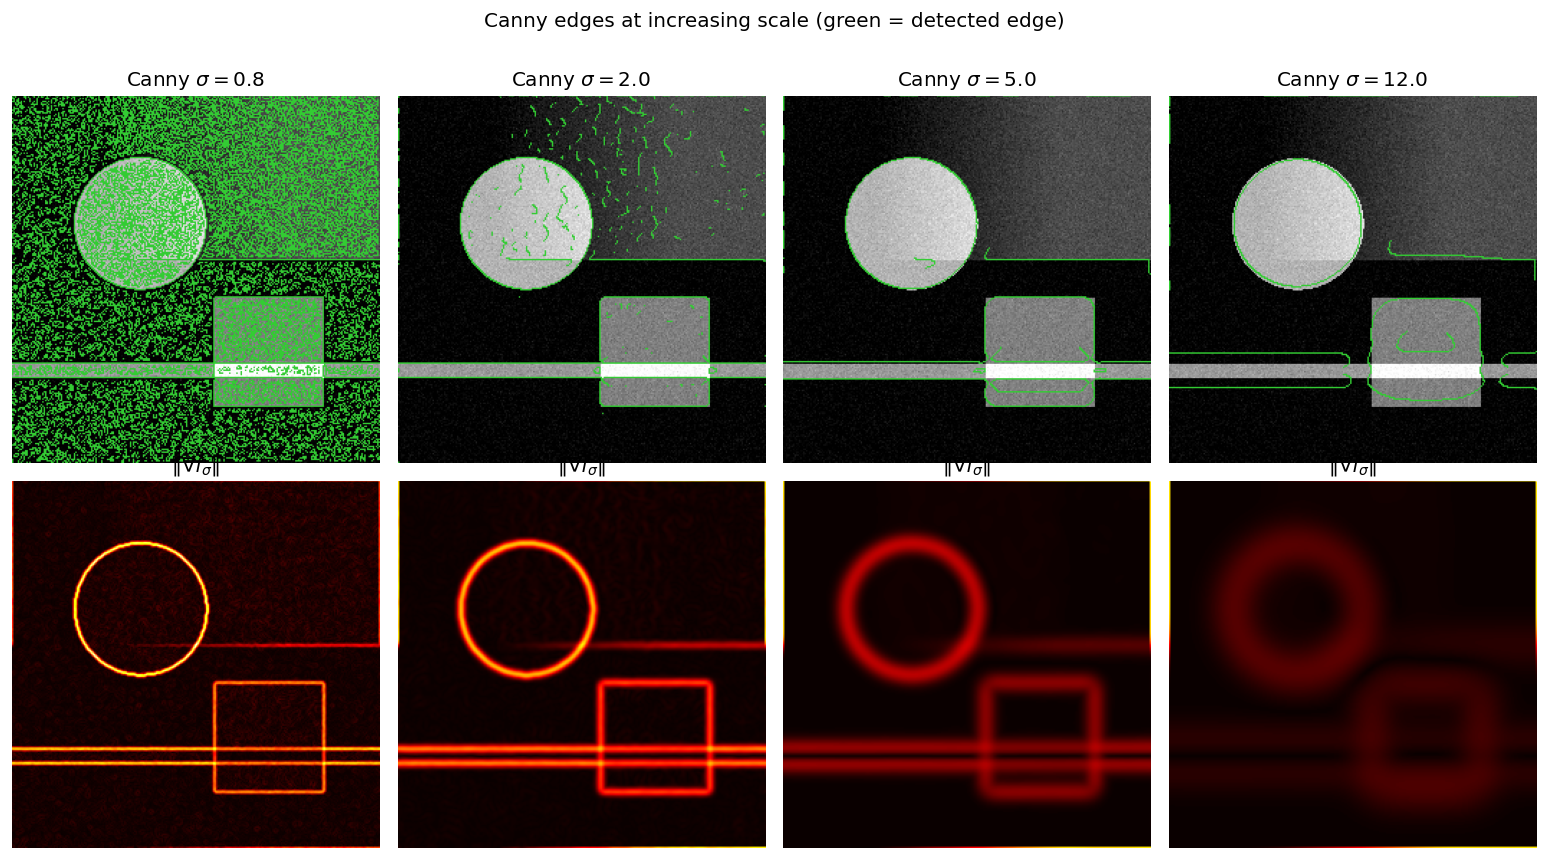

In [5]:
def hessian(f):
    """Return (fxx, fxy, fyy) using centered differences."""
    fxx = np.roll(f,-1,1) + np.roll(f,1,1) - 2*f
    fyy = np.roll(f,-1,0) + np.roll(f,1,0) - 2*f
    fxy = (np.roll(np.roll(f,-1,0),-1,1) - np.roll(np.roll(f,-1,0),1,1)
           - np.roll(np.roll(f,1,0),-1,1) + np.roll(np.roll(f,1,0),1,1)) / 4
    return fxx, fxy, fyy


def canny_map(f, sigma, threshold=0.0):
    """Compute Canny directional-second-derivative map and its zero-crossings."""
    fs = gaussian_filter(f, sigma)
    gx, gy = grad(fs)
    fxx, fxy, fyy = hessian(fs)
    # <H*nabla, nabla>
    D = fxx*gx**2 + 2*fxy*gx*gy + fyy*gy**2
    gmag = np.sqrt(gx**2 + gy**2)
    zc = zero_crossings(D)
    return zc & (gmag > threshold), gmag


fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for j, sigma in enumerate([0.8, 2.0, 5.0, 12.0]):
    edges, gmag = canny_map(img_noisy, sigma, threshold=0.005)
    disp = np.stack([img_noisy]*3, axis=-1)
    disp[edges] = [0.2, 0.8, 0.2]
    axes[0, j].imshow(np.clip(disp, 0, 1))
    axes[0, j].set_title(f"Canny $\\sigma={sigma}$"); axes[0, j].axis("off")
    axes[1, j].imshow(gmag, cmap="hot")
    axes[1, j].set_title(f"$\\|\\nabla f_\\sigma\\|$"); axes[1, j].axis("off")
fig.suptitle("Canny edges at increasing scale (green = detected edge)", y=1.02)
plt.tight_layout()
plt.show()

## Interactive detector comparison

Adjust the smoothing scale $\sigma$ and switch between the three detectors to observe the scale–noise trade-off in real time.

In [6]:
from ipywidgets import Dropdown

def show_edges(detector="canny", sigma=2.0, threshold=0.01):
    fs = gaussian_filter(img_noisy, sigma)
    gx, gy = grad(fs)
    gmag = np.sqrt(gx**2 + gy**2)

    if detector == "gradient":
        binary = gmag > threshold
        title = f"Gradient magnitude > {threshold:.3f}"
    elif detector == "laplacian":
        binary = zero_crossings(laplacian(fs))
        title = "Laplacian zero-crossings"
    else:
        binary, _ = canny_map(img_noisy, sigma, threshold)
        title = f"Canny  (threshold={threshold:.3f})"

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    axes[0].imshow(fs, cmap="gray"); axes[0].set_title(f"$f_\\sigma$, $\\sigma={sigma}$")
    axes[0].axis("off")
    disp = np.stack([img_noisy]*3, axis=-1)
    disp[binary] = [0.2, 1.0, 0.2]
    axes[1].imshow(np.clip(disp, 0, 1))
    axes[1].set_title(title); axes[1].axis("off")
    plt.tight_layout(); plt.show()

interact(
    show_edges,
    detector=Dropdown(options=["gradient","laplacian","canny"], description="detector"),
    sigma=FloatSlider(value=2.0, min=0.3, max=15.0, step=0.3, description="$\\sigma$"),
    threshold=FloatSlider(value=0.01, min=0.001, max=0.05, step=0.002,
                          description="thresh"),
);

interactive(children=(Dropdown(description='detector', options=('gradient', 'laplacian', 'canny'), value='grad…

## Bibliographical resources

- Marr, D. and Hildreth, E. (1980). Theory of edge detection. *Proceedings of the Royal Society B*, 207(1167), 187–217.
- Canny, J. (1986). A computational approach to edge detection. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 8(6), 679–698.
- Koenderink, J. J. (1984). The structure of images. *Biological Cybernetics*, 50(5), 363–370.
- Witkin, A. P. (1983). Scale-space filtering. *IJCAI*, 1019–1022.
- Lindeberg, T. (1994). *Scale-Space Theory in Computer Vision*. Springer.